# E_S2 — RF Atom Classifier (Basic Workflow)

Train a Random Forest to classify scatter plots into 6 atomic shape classes:
**linear, convex, concave, inflected, u_shape, spike**

**Pipeline**: Load data → Build x-bin profiles → Filter visibility zones →
Train/test split → RF training → Evaluation (10 steps)

In [17]:
from __future__ import annotations

import math
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))

DATA_DIR = Path('output/S1')
OUT_DIR = Path('output/S2')
OUT_DIR.mkdir(parents=True, exist_ok=True)

_ALL_COLORS = {
    'linear': '#636363', 'convex': '#e6550d', 'concave': '#3182bd',
    'inflected': '#31a354', 's_curve': '#2ca02c', 'threshold': '#bcbddc',
    'u_shape': '#756bb1', 'spike': '#e7298a', 'saturation': '#d95f0e',
    'two_lines': '#2E7D32', 'line_parab': '#FF7043',
}
_FALLBACK = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

## Step 1: Load Data

In [18]:
cases = pd.read_csv(DATA_DIR / 'cases.csv')
points = np.load(DATA_DIR / 'scatter_points.npz')
x_all, y_all = points['x'], points['y']

cases['snr_float'] = cases['snr'].apply(lambda v: math.inf if str(v) == 'inf' else float(v))

# Dynamic atom order and colors from data
ATOM_ORDER = sorted(cases['atom_class'].unique())
ATOM_COLORS = {}
for i, a in enumerate(ATOM_ORDER):
    ATOM_COLORS[a] = _ALL_COLORS.get(a, _FALLBACK[i % len(_FALLBACK)])

print(f'Cases: {len(cases):,}')
print(f'Scatter arrays: x={x_all.shape}, y={y_all.shape}')
print(f'Atom classes ({len(ATOM_ORDER)}): {ATOM_ORDER}')
print()
print(cases.groupby('atom_class')['case_id'].count().reindex(ATOM_ORDER))

Cases: 217,080
Scatter arrays: x=(217080, 500), y=(217080, 500)
Atom classes (8): ['concave', 'convex', 'inflected', 'line_parab', 'linear', 'spike', 'two_lines', 'u_shape']

atom_class
concave       24120
convex        24120
inflected     48240
line_parab    24120
linear        24120
spike         24120
two_lines     24120
u_shape       24120
Name: case_id, dtype: int64


## Step 2: Build x-bin Profile Features

For each scatter plot, divide x ∈ [0, 1] into 20 equal-width bins.
Within each bin, compute 4 statistics on **robustly scaled y**:
- `median_y` — robust center
- `iqr_y` — spread
- `count_ratio` — point density (count / expected)
- `is_empty` — 1 if bin has < 3 points

Plus **3 curvature features** derived from the bin-median profile:
- `resid_quad_coef` — quadratic coefficient from fitting linear residuals
- `resid_std` — std of linear-fit residuals (0 for truly linear)
- `delta_bic` — BIC(linear) − BIC(quadratic); positive = curvature detected

→ 20 bins × 4 stats + 3 curvature = **83-dimensional** feature vector.

In [19]:
N_BINS = 20
BIN_EDGES = np.linspace(0.0, 1.0, N_BINS + 1)
BIN_MIDS = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2
MIN_BIN_COUNT = 3
N_CURV_FEAT = 3
N_FEATURES = N_BINS * 4 + N_CURV_FEAT


def xbin_profile(x, y):
    med_y = np.median(y)
    iqr_y = np.subtract(*np.percentile(y, [75, 25]))
    if iqr_y < 1e-12:
        iqr_y = 1.0
    y_s = (y - med_y) / iqr_y

    features = np.zeros(N_FEATURES, dtype=np.float32)
    expected = len(x) / N_BINS
    bin_medians = np.zeros(N_BINS, dtype=np.float64)
    bin_valid = np.zeros(N_BINS, dtype=bool)

    for b in range(N_BINS):
        lo, hi = BIN_EDGES[b], BIN_EDGES[b + 1]
        if b == N_BINS - 1:
            mask = (x >= lo) & (x <= hi)
        else:
            mask = (x >= lo) & (x < hi)
        yb = y_s[mask]
        cnt = len(yb)

        base = b * 4
        if cnt >= MIN_BIN_COUNT:
            features[base + 0] = np.median(yb)
            features[base + 1] = np.subtract(*np.percentile(yb, [75, 25]))
            bin_medians[b] = features[base + 0]
            bin_valid[b] = True
        else:
            features[base + 3] = 1.0
        features[base + 2] = cnt / expected if expected > 0 else 0.0

    # Curvature features from bin-median profile
    curv_base = N_BINS * 4
    valid_idx = np.where(bin_valid)[0]
    if len(valid_idx) >= 4:
        xv = BIN_MIDS[valid_idx]
        yv = bin_medians[valid_idx]
        n_v = len(xv)

        # Linear fit + residuals
        c1 = np.polyfit(xv, yv, 1)
        resid = yv - np.polyval(c1, xv)
        features[curv_base + 1] = np.std(resid)

        # Quadratic fit to residuals → curvature coefficient
        c2_resid = np.polyfit(xv, resid, 2)
        features[curv_base + 0] = c2_resid[0]

        # Delta BIC: BIC_linear - BIC_quadratic
        rss1 = np.sum(resid ** 2)
        c2 = np.polyfit(xv, yv, 2)
        rss2 = np.sum((yv - np.polyval(c2, xv)) ** 2)
        k1, k2 = 2, 3
        if rss1 > 1e-30 and rss2 > 1e-30:
            bic1 = n_v * np.log(rss1 / n_v) + k1 * np.log(n_v)
            bic2 = n_v * np.log(rss2 / n_v) + k2 * np.log(n_v)
            features[curv_base + 2] = bic1 - bic2
        elif rss1 > 1e-30:
            features[curv_base + 2] = 50.0

    return features


print('Building x-bin profiles + curvature features...')
n = len(cases)
X_feat = np.empty((n, N_FEATURES), dtype=np.float32)
for i in range(n):
    X_feat[i] = xbin_profile(x_all[i], y_all[i])
    if (i + 1) % 50000 == 0:
        print(f'  {i+1:>7,}/{n:,}')

print(f'Feature matrix: {X_feat.shape}  ({N_BINS}×4 bin stats + {N_CURV_FEAT} curvature)')
print(f'NaN count: {np.isnan(X_feat).sum()}')

Building x-bin profiles + curvature features...
   50,000/217,080
  100,000/217,080
  150,000/217,080
  200,000/217,080
Feature matrix: (217080, 83)  (20×4 bin stats + 3 curvature)
NaN count: 0


## Step 3: Three-Zone Filtering

- **Visible** (SNR ≥ CLEAR_SNR): use for training/testing
- **Fuzzy** (THRESHOLD < SNR < CLEAR): held out for calibration
- **Invisible** (SNR ≤ THRESHOLD): excluded entirely

In [20]:
CLEAR_SNR = {
    'F01': 2.0, 'F02': 2.0,
    'F03': 2.0, 'F04': 2.0, 'F05': 2.0, 'F06': 2.0,
    'F13': 15.0, 'F14': 15.0,
    'F15': 2.0, 'F16': 2.0,
    'F17': 1.0, 'F18': 1.0,
    'F19': 1.0, 'F20': 1.0,
    'F21': 2.0, 'F22': 2.0,
    'F23': 12.0, 'F24': 12.0,
}

THRESHOLD_SNR = {
    'F01': 0.3, 'F02': 0.3,
    'F03': 0.3, 'F04': 0.3, 'F05': 0.3, 'F06': 0.3,
    'F13': 7.0, 'F14': 7.0,
    'F15': 0.5, 'F16': 0.5,
    'F17': 0.3, 'F18': 0.3,
    'F19': 0.1, 'F20': 0.1,
    'F21': 0.3, 'F22': 0.3,
    'F23': 3.0, 'F24': 3.0,
}


def assign_zone(row):
    fid = row['family_id']
    snr = row['snr_float']
    if snr >= CLEAR_SNR.get(fid, 2.0):
        return 'visible'
    elif snr > THRESHOLD_SNR.get(fid, 0.3):
        return 'fuzzy'
    else:
        return 'invisible'


cases['zone'] = cases.apply(assign_zone, axis=1)

zone_counts = cases.groupby(['zone', 'atom_class'])['case_id'].count().unstack(fill_value=0)
zone_counts = zone_counts.reindex(columns=ATOM_ORDER)
print(zone_counts)
print(f'\nTotal visible: {(cases["zone"] == "visible").sum():,}')
print(f'Total fuzzy: {(cases["zone"] == "fuzzy").sum():,}')
print(f'Total invisible: {(cases["zone"] == "invisible").sum():,}')

atom_class  concave  convex  inflected  line_parab  linear  spike  two_lines  \
zone                                                                           
fuzzy          3480    3480       3840        2520    3480   4200       2520   
invisible     10440   10440      27600       14640   10440   8400      14640   
visible       10200   10200      16800        6960   10200  11520       6960   

atom_class  u_shape  
zone                 
fuzzy          2160  
invisible     10440  
visible       11520  

Total visible: 84,360
Total fuzzy: 25,680
Total invisible: 107,040


## Step 4: Train/Test Split

Use **StratifiedGroupKFold** with groups = shape_config_id.
This ensures all replicates of the same config stay in the same fold
(no data leakage from same-config different-replicate).

Compare: all variants vs standard+strong only.

In [21]:
vis_mask = cases['zone'] == 'visible'

# Training pool: ALL visible (mild+standard+strong)
X_vis = X_feat[vis_mask.values]
y_vis = cases.loc[vis_mask, 'atom_class'].values
groups_vis = cases.loc[vis_mask, 'shape_config_id'].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
fold_assignments = np.full(len(y_vis), -1, dtype=int)
for fold_i, (_, test_idx) in enumerate(sgkf.split(X_vis, y_vis, groups_vis)):
    fold_assignments[test_idx] = fold_i

train_mask = fold_assignments != 0
test_mask = fold_assignments == 0

X_train, y_train = X_vis[train_mask], y_vis[train_mask]
X_test, y_test = X_vis[test_mask], y_vis[test_mask]

print(f'Visible cases (all variants): {len(X_vis):,}')
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}')
print(f'\nTrain class distribution:')
for atom in ATOM_ORDER:
    print(f'  {atom:<12s}: {(y_train == atom).sum():>6,}')
print(f'\nTest class distribution:')
for atom in ATOM_ORDER:
    print(f'  {atom:<12s}: {(y_test == atom).sum():>6,}')

Visible cases (all variants): 84,360
Train: 66,960  Test: 17,400

Train class distribution:
  concave     :  6,800
  convex      : 10,200
  inflected   : 11,200
  line_parab  :  6,960
  linear      :  6,800
  spike       :  9,600
  two_lines   :  5,800
  u_shape     :  9,600

Test class distribution:
  concave     :  3,400
  convex      :      0
  inflected   :  5,600
  line_parab  :      0
  linear      :  3,400
  spike       :  1,920
  two_lines   :  1,160
  u_shape     :  1,920


## Step 5: Train Random Forest

In [22]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=3,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)

print('Training Random Forest...')
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

print(f'Train accuracy: {accuracy_score(y_train, y_pred_train):.4f}')
print(f'Test accuracy:  {accuracy_score(y_test, y_pred_test):.4f}')

Training Random Forest...


Train accuracy: 0.9995
Test accuracy:  0.9787


## Evaluation 1: Confusion Matrix

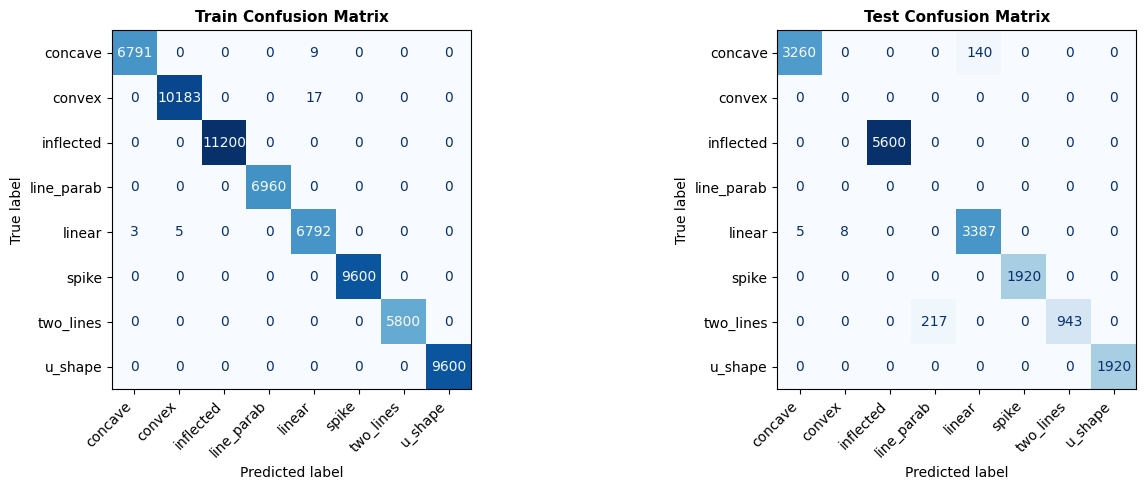


── Test Classification Report ──
              precision    recall  f1-score   support

     concave      0.998     0.959     0.978      3400
      convex      0.000     0.000     0.000         0
   inflected      1.000     1.000     1.000      5600
  line_parab      0.000     0.000     0.000         0
      linear      0.960     0.996     0.978      3400
       spike      1.000     1.000     1.000      1920
   two_lines      1.000     0.813     0.897      1160
     u_shape      1.000     1.000     1.000      1920

    accuracy                          0.979     17400
   macro avg      0.745     0.721     0.732     17400
weighted avg      0.992     0.979     0.985     17400



/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_train, y_pred_train, 'Train'),
    (axes[1], y_test, y_pred_test, 'Test'),
]:
    cm = confusion_matrix(y_true, y_pred, labels=ATOM_ORDER)
    disp = ConfusionMatrixDisplay(cm, display_labels=ATOM_ORDER)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f'{title} Confusion Matrix', fontsize=11, fontweight='bold')
    ax.set_xticklabels(ATOM_ORDER, rotation=45, ha='right')

plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Test Classification Report ──')
print(classification_report(y_test, y_pred_test, labels=ATOM_ORDER, target_names=ATOM_ORDER, digits=3))

## Evaluation 2: Accuracy vs SNR

How does accuracy degrade as noise increases?

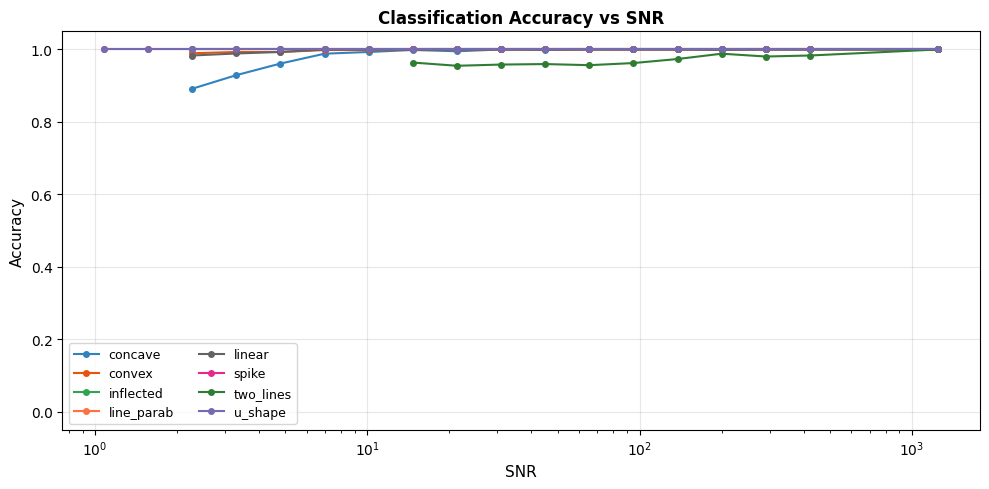

In [24]:
vis_cases = cases[vis_mask].copy()
vis_cases['pred'] = np.concatenate([
    y_pred_train if i else y_pred_test
    for i, mask in [(True, train_mask), (False, test_mask)]
    for _ in [None]
], axis=0) if False else ''  # placeholder

# Re-predict all visible with the trained model
vis_cases['pred'] = rf.predict(X_vis)
vis_cases['correct'] = vis_cases['pred'] == vis_cases['atom_class']

snr_bins = np.geomspace(0.01, 500, 30)
vis_cases['snr_bin'] = pd.cut(vis_cases['snr_float'].replace(math.inf, 1000),
                               bins=[0] + snr_bins.tolist() + [2000])

fig, ax = plt.subplots(figsize=(10, 5))
for atom in ATOM_ORDER:
    sub = vis_cases[vis_cases['atom_class'] == atom]
    acc = sub.groupby('snr_bin', observed=True)['correct'].mean()
    midpoints = [(iv.left + iv.right) / 2 for iv in acc.index]
    ax.plot(midpoints, acc.values, '-o', label=atom, color=ATOM_COLORS[atom],
            markersize=4, linewidth=1.5)

ax.set_xscale('log')
ax.set_xlabel('SNR', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Classification Accuracy vs SNR', fontsize=12, fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'accuracy_vs_snr.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation 3: Feature Importance

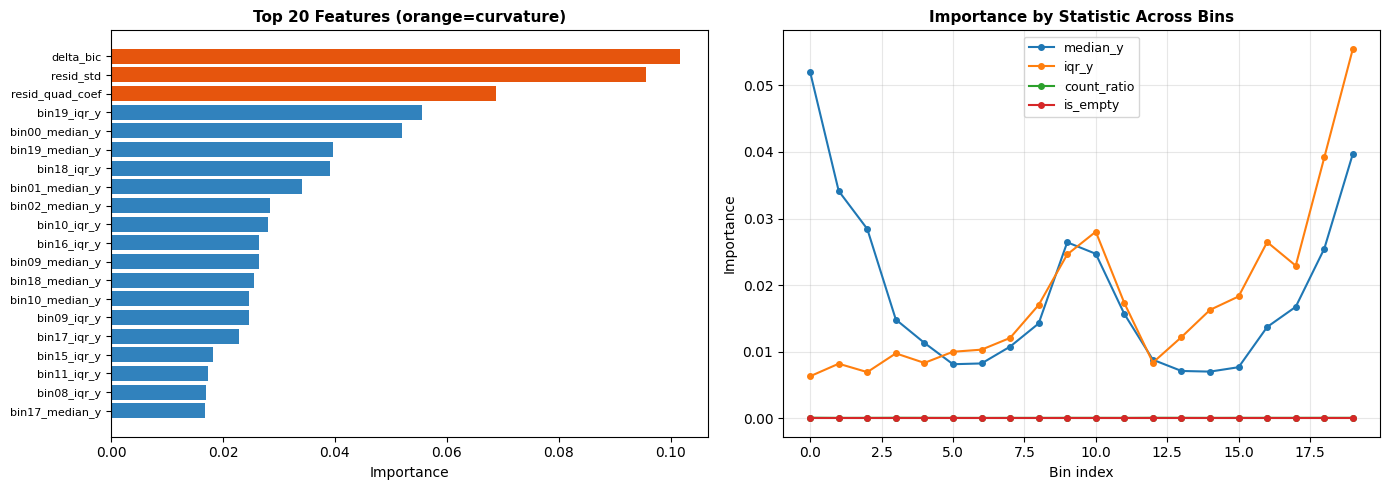

Top 15 features:
        feature  importance
      delta_bic    0.101559
      resid_std    0.095508
resid_quad_coef    0.068722
    bin19_iqr_y    0.055489
 bin00_median_y    0.052002
 bin19_median_y    0.039726
    bin18_iqr_y    0.039169
 bin01_median_y    0.034132
 bin02_median_y    0.028432
    bin10_iqr_y    0.028018
    bin16_iqr_y    0.026458
 bin09_median_y    0.026429
 bin18_median_y    0.025471
 bin10_median_y    0.024697
    bin09_iqr_y    0.024602

Curvature features:
        feature  importance
      delta_bic    0.101559
      resid_std    0.095508
resid_quad_coef    0.068722


In [25]:
importances = rf.feature_importances_
feat_names = []
stat_names = ['median_y', 'iqr_y', 'count_ratio', 'is_empty']
for b in range(N_BINS):
    for s in stat_names:
        feat_names.append(f'bin{b:02d}_{s}')
feat_names += ['resid_quad_coef', 'resid_std', 'delta_bic']

imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 features
ax = axes[0]
top20 = imp_df.head(20)
colors = ['#e6550d' if 'resid' in f or 'bic' in f else '#3182bd' for f in top20['feature']]
ax.barh(range(20), top20['importance'].values, color=colors)
ax.set_yticks(range(20))
ax.set_yticklabels(top20['feature'].values, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Top 20 Features (orange=curvature)', fontsize=11, fontweight='bold')

# Importance by stat type (bin features only)
ax = axes[1]
for si, stat in enumerate(stat_names):
    vals = importances[si:N_BINS*4:4]
    ax.plot(range(N_BINS), vals, '-o', label=stat, markersize=4, linewidth=1.5)
ax.set_xlabel('Bin index')
ax.set_ylabel('Importance')
ax.set_title('Importance by Statistic Across Bins', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 features:')
print(imp_df.head(15).to_string(index=False))
print(f'\nCurvature features:')
print(imp_df[imp_df['feature'].isin(['resid_quad_coef', 'resid_std', 'delta_bic'])].to_string(index=False))

## Evaluation 4: Per-Family Accuracy

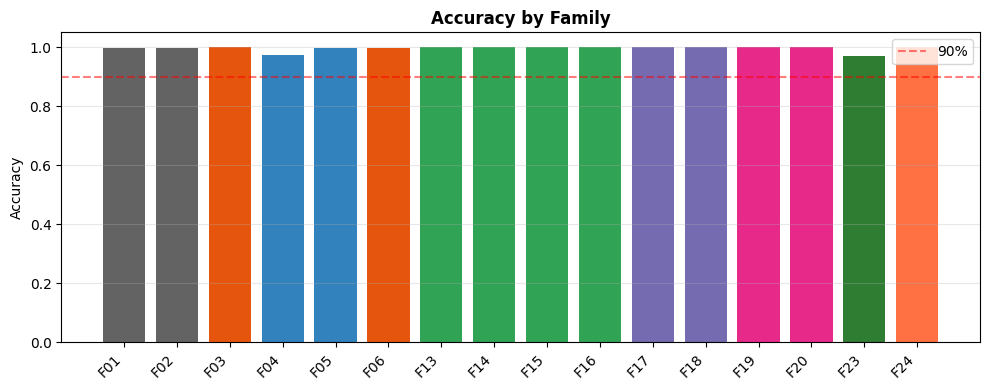

family_id atom_class  accuracy
      F01     linear  0.997843
      F02     linear  0.998039
      F03     convex  0.999216
      F04    concave  0.972549
      F05    concave  0.998235
      F06     convex  0.997451
      F13  inflected  1.000000
      F14  inflected  1.000000
      F15  inflected  1.000000
      F16  inflected  1.000000
      F17    u_shape  1.000000
      F18    u_shape  1.000000
      F19      spike  1.000000
      F20      spike  1.000000
      F23  two_lines  0.968822
      F24 line_parab  1.000000


In [26]:
vis_cases['correct'] = vis_cases['pred'] == vis_cases['atom_class']

fam_acc = vis_cases.groupby(['family_id', 'atom_class'])['correct'].mean().reset_index()
fam_acc.columns = ['family_id', 'atom_class', 'accuracy']
fam_acc = fam_acc.sort_values('family_id')

fig, ax = plt.subplots(figsize=(10, 4))
colors = [ATOM_COLORS[a] for a in fam_acc['atom_class']]
bars = ax.bar(range(len(fam_acc)), fam_acc['accuracy'], color=colors)
ax.set_xticks(range(len(fam_acc)))
ax.set_xticklabels(fam_acc['family_id'], rotation=45, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Family', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.axhline(0.9, color='red', linestyle='--', alpha=0.5, label='90%')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'accuracy_by_family.png', dpi=150, bbox_inches='tight')
plt.show()

print(fam_acc.to_string(index=False))

## Evaluation 5: Per-Variant Accuracy

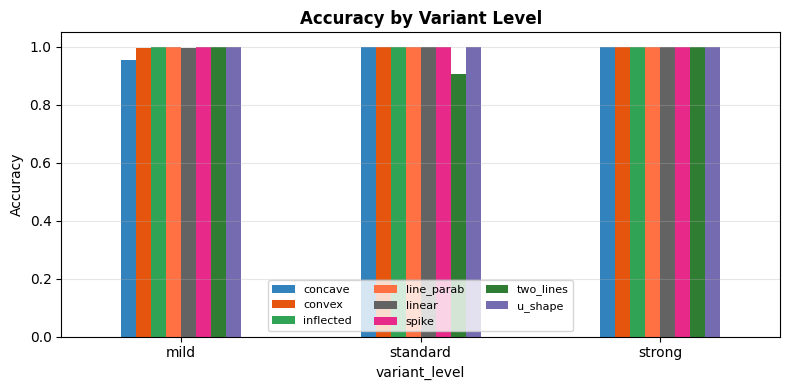

atom_class     concave  convex  inflected  line_parab  linear  spike  \
variant_level                                                          
mild             0.956   0.995        1.0         1.0   0.997    1.0   
standard         1.000   1.000        1.0         1.0   0.998    1.0   
strong           1.000   1.000        1.0         1.0   0.999    1.0   

atom_class     two_lines  u_shape  
variant_level                      
mild               1.000      1.0  
standard           0.906      1.0  
strong             1.000      1.0  


In [27]:
var_acc = vis_cases.groupby(['variant_level', 'atom_class'])['correct'].mean().unstack()
var_acc = var_acc.reindex(columns=ATOM_ORDER, index=['mild', 'standard', 'strong'])

fig, ax = plt.subplots(figsize=(8, 4))
var_acc.plot(kind='bar', ax=ax, color=[ATOM_COLORS[a] for a in ATOM_ORDER])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Variant Level', fontsize=12, fontweight='bold')
ax.set_xticklabels(['mild', 'standard', 'strong'], rotation=0)
ax.set_ylim(0, 1.05)
ax.legend(ncol=3, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'accuracy_by_variant.png', dpi=150, bbox_inches='tight')
plt.show()

print(var_acc.round(3))

## Evaluation 6: Prediction Confidence

RF probability for predicted class — high-confidence correct vs low-confidence errors.

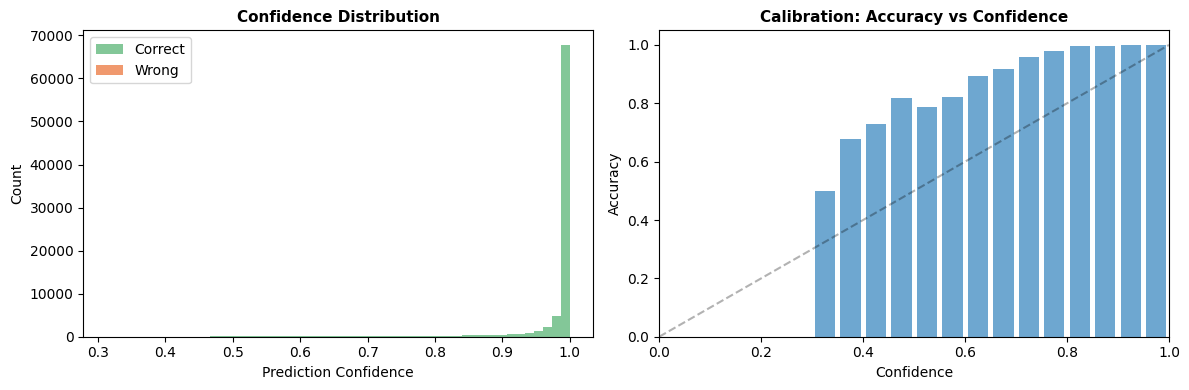

Mean confidence (correct): 0.977
Mean confidence (wrong):   0.569


In [28]:
proba = rf.predict_proba(X_vis)
pred_conf = proba.max(axis=1)

vis_cases['confidence'] = pred_conf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(pred_conf[vis_cases['correct'].values], bins=50, alpha=0.6, color='#31a354', label='Correct')
ax.hist(pred_conf[~vis_cases['correct'].values], bins=50, alpha=0.6, color='#e6550d', label='Wrong')
ax.set_xlabel('Prediction Confidence')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution', fontsize=11, fontweight='bold')
ax.legend()

ax = axes[1]
conf_bins = np.linspace(0, 1, 21)
vis_cases['conf_bin'] = pd.cut(vis_cases['confidence'], bins=conf_bins)
conf_acc = vis_cases.groupby('conf_bin', observed=True)['correct'].agg(['mean', 'count'])
midpoints = [(iv.left + iv.right) / 2 for iv in conf_acc.index]
ax.bar(midpoints, conf_acc['mean'], width=0.04, color='#3182bd', alpha=0.7)
ax.set_xlabel('Confidence')
ax.set_ylabel('Accuracy')
ax.set_title('Calibration: Accuracy vs Confidence', fontsize=11, fontweight='bold')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(OUT_DIR / 'confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean confidence (correct): {pred_conf[vis_cases["correct"].values].mean():.3f}')
print(f'Mean confidence (wrong):   {pred_conf[~vis_cases["correct"].values].mean():.3f}')

## Evaluation 7: Rejection Mechanism

If we reject predictions below a confidence threshold, how does accuracy improve?

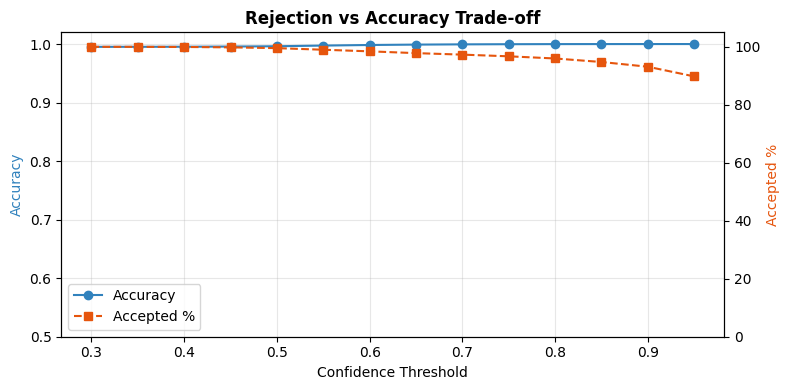

 threshold  accepted_pct  accuracy
     0.300       100.000     0.995
     0.350        99.993     0.995
     0.400        99.953     0.995
     0.450        99.817     0.996
     0.500        99.546     0.996
     0.550        98.996     0.997
     0.600        98.444     0.998
     0.650        97.826     0.999
     0.700        97.309     0.999
     0.750        96.727     1.000
     0.800        95.980     1.000
     0.850        94.766     1.000
     0.900        93.133     1.000
     0.950        89.795     1.000


In [29]:
thresholds = np.arange(0.3, 0.96, 0.05)
reject_results = []

for t in thresholds:
    accepted = vis_cases['confidence'] >= t
    if accepted.sum() == 0:
        continue
    acc = vis_cases.loc[accepted, 'correct'].mean()
    reject_results.append({
        'threshold': t,
        'accepted_pct': 100 * accepted.mean(),
        'accuracy': acc,
    })

rej_df = pd.DataFrame(reject_results)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.plot(rej_df['threshold'], rej_df['accuracy'], 'o-', color='#3182bd', label='Accuracy')
ax2.plot(rej_df['threshold'], rej_df['accepted_pct'], 's--', color='#e6550d', label='Accepted %')

ax1.set_xlabel('Confidence Threshold')
ax1.set_ylabel('Accuracy', color='#3182bd')
ax2.set_ylabel('Accepted %', color='#e6550d')
ax1.set_title('Rejection vs Accuracy Trade-off', fontsize=12, fontweight='bold')
ax1.set_ylim(0.5, 1.02)
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'rejection_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print(rej_df.to_string(index=False, float_format='{:.3f}'.format))

## Evaluation 8: Fuzzy Zone Performance

How does the model perform in the fuzzy zone (between THRESHOLD and CLEAR SNR)?

Fuzzy zone: 25,680 cases
Accuracy: 0.8121
Mean confidence: 0.667

            accuracy  mean_conf  count
atom_class                            
concave        0.619      0.521   3480
convex         0.728      0.591   3480
inflected      0.835      0.665   3840
line_parab     0.933      0.779   2520
linear         0.567      0.459   3480
spike          1.000      0.928   4200
two_lines      0.929      0.699   2520
u_shape        0.970      0.686   2160


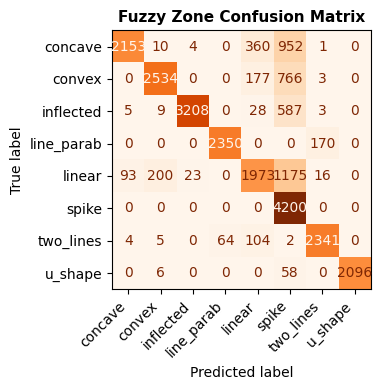

In [30]:
fuzzy_mask = cases['zone'] == 'fuzzy'
if fuzzy_mask.sum() > 0:
    X_fuzzy = X_feat[fuzzy_mask.values]
    y_fuzzy = cases.loc[fuzzy_mask, 'atom_class'].values
    fuzzy_cases = cases[fuzzy_mask].copy()

    y_fuzzy_pred = rf.predict(X_fuzzy)
    fuzzy_conf = rf.predict_proba(X_fuzzy).max(axis=1)

    fuzzy_cases['pred'] = y_fuzzy_pred
    fuzzy_cases['correct'] = y_fuzzy_pred == y_fuzzy
    fuzzy_cases['confidence'] = fuzzy_conf

    print(f'Fuzzy zone: {len(X_fuzzy):,} cases')
    print(f'Accuracy: {accuracy_score(y_fuzzy, y_fuzzy_pred):.4f}')
    print(f'Mean confidence: {fuzzy_conf.mean():.3f}')
    print()

    fuzzy_by_atom = fuzzy_cases.groupby('atom_class').agg(
        accuracy=('correct', 'mean'),
        mean_conf=('confidence', 'mean'),
        count=('correct', 'count'),
    ).reindex(ATOM_ORDER)
    print(fuzzy_by_atom.round(3))

    fig, ax = plt.subplots(figsize=(8, 4))
    cm = confusion_matrix(y_fuzzy, y_fuzzy_pred, labels=ATOM_ORDER)
    ConfusionMatrixDisplay(cm, display_labels=ATOM_ORDER).plot(ax=ax, cmap='Oranges',
                                                               values_format='d', colorbar=False)
    ax.set_title('Fuzzy Zone Confusion Matrix', fontsize=11, fontweight='bold')
    ax.set_xticklabels(ATOM_ORDER, rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fuzzy_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No fuzzy zone cases found.')

## Evaluation 9: Error Analysis

Show the worst misclassified cases.

Total errors: 404 / 84,360 (0.48%)

Top confusion pairs:
atom_class       pred  count
 two_lines line_parab    217
   concave     linear    149
    convex     linear     17
    linear     convex     13
    linear    concave      8


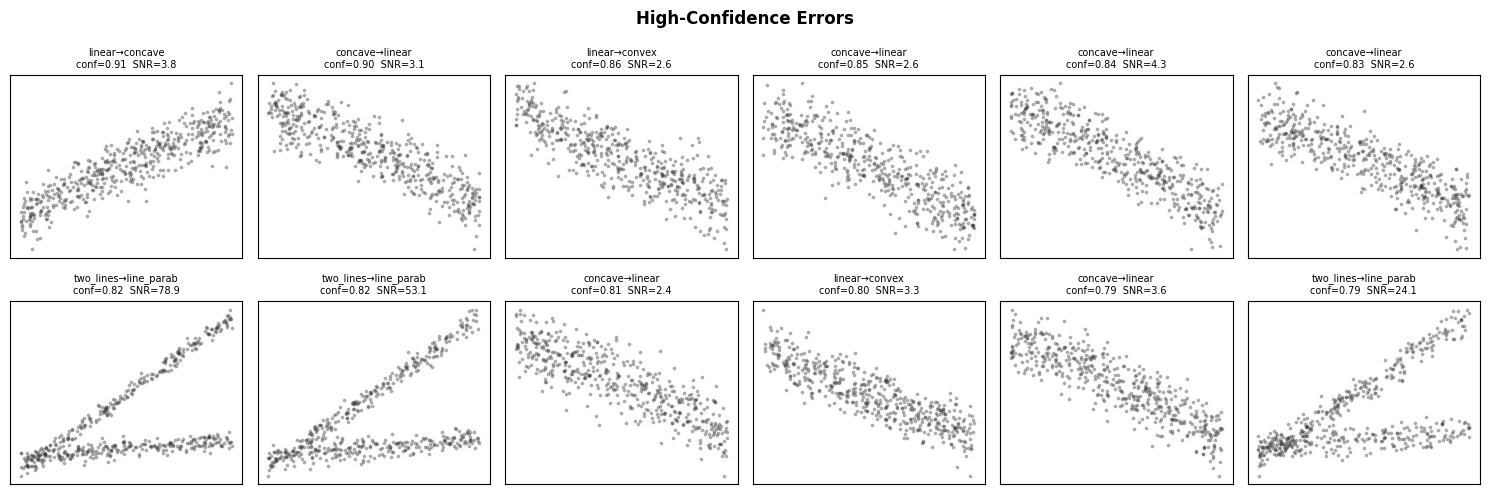

In [31]:
errors = vis_cases[~vis_cases['correct']].copy()
errors = errors.sort_values('confidence', ascending=False)

print(f'Total errors: {len(errors):,} / {len(vis_cases):,} ({100*len(errors)/len(vis_cases):.2f}%)')
print()

# Most common confusion pairs
confusion_pairs = errors.groupby(['atom_class', 'pred']).size().reset_index(name='count')
confusion_pairs = confusion_pairs.sort_values('count', ascending=False)
print('Top confusion pairs:')
print(confusion_pairs.head(10).to_string(index=False))

# Show 12 worst high-confidence errors
n_show = min(12, len(errors))
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
axes = axes.ravel()

for i in range(n_show):
    row = errors.iloc[i]
    idx = row.name
    ax = axes[i]
    ax.scatter(x_all[idx], y_all[idx], s=3, alpha=0.3, color='#333')
    ax.set_title(f'{row["atom_class"]}→{row["pred"]}\nconf={row["confidence"]:.2f}  SNR={row["snr_float"]:.1f}',
                 fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

for i in range(n_show, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('High-Confidence Errors', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation 10: 5-Fold Cross-Validation

Full cross-validated accuracy with grouped splits.

Running 5-fold cross-validation (all variants)...

5-fold CV accuracy (all variants): 0.9703

              precision    recall  f1-score   support

     concave      0.994     0.967     0.980     10200
      convex      0.994     0.964     0.979     10200
   inflected      1.000     0.928     0.963     16800
  line_parab      0.970     0.999     0.984      6960
      linear      0.826     0.996     0.903     10200
       spike      1.000     0.998     0.999     11520
   two_lines      0.999     0.926     0.961      6960
     u_shape      0.998     1.000     0.999     11520

    accuracy                          0.970     84360
   macro avg      0.973     0.972     0.971     84360
weighted avg      0.975     0.970     0.971     84360



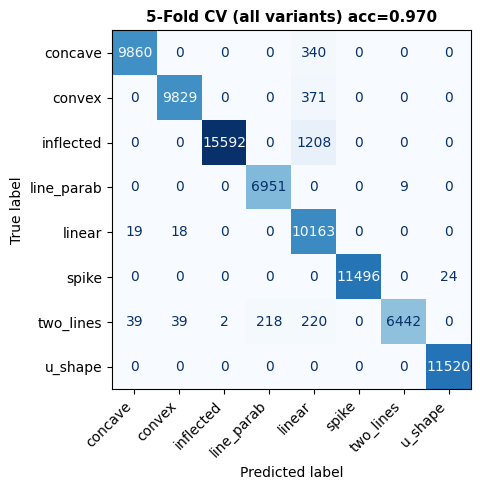

In [32]:
print('Running 5-fold cross-validation (all variants)...')
y_cv = cross_val_predict(
    RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=3,
        class_weight='balanced', n_jobs=-1, random_state=42,
    ),
    X_vis, y_vis, groups=groups_vis,
    cv=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1,
)

cv_acc = accuracy_score(y_vis, y_cv)
print(f'\n5-fold CV accuracy (all variants): {cv_acc:.4f}')
print()
print(classification_report(y_vis, y_cv, labels=ATOM_ORDER, target_names=ATOM_ORDER, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_vis, y_cv, labels=ATOM_ORDER)
ConfusionMatrixDisplay(cm, display_labels=ATOM_ORDER).plot(ax=ax, cmap='Blues',
                                                           values_format='d', colorbar=False)
ax.set_title(f'5-Fold CV (all variants) acc={cv_acc:.3f}', fontsize=11, fontweight='bold')
ax.set_xticklabels(ATOM_ORDER, rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cv_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Metric | Value |
|--------|-------|
| Features | 80 (20 bins × 4 stats) |
| Atom classes | 6 |
| Families | 14 |
| Model | Random Forest (200 trees, balanced) |

**Next steps**:
- Tune RF hyperparameters (if needed)
- Test on composite (multi-atom) scatter plots
- Integrate with visibility model (Model A)